In [1]:
#Step 1 : Importing the necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#step 2: Load the data
# Transformation for the Images
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Function to fix the Labels (1,2,3 -> 0,1,2)
def fix_mask(mask):
    mask = transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.NEAREST)(mask)
    return torch.as_tensor(np.array(mask), dtype=torch.long) - 1

# Download
train_dataset = datasets.OxfordIIITPet(root='./data', split='trainval',
                                       target_types='segmentation', download=True,
                                       transform=transform, target_transform=fix_mask)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dataset Loaded. Using: {device}")

100%|██████████| 792M/792M [00:41<00:00, 19.1MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.3MB/s]


Dataset Loaded. Using: cuda


In [3]:
#sTep 3: The U-net model
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Conv2d(3, 64, 3, padding=1)
        self.enc2 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.up = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec = nn.Conv2d(128, 64, 3, padding=1)
        self.final = nn.Conv2d(64, 3, 1)

    def forward(self, x):
        x1 = torch.relu(self.enc1(x))
        x2 = self.pool(x1)
        x2 = torch.relu(self.enc2(x2))
        x3 = self.up(x2)
        x4 = torch.cat([x3, x1], dim=1) # Skip Connection
        return self.final(torch.relu(self.dec(x4)))

In [4]:
#Step 4: Training function
def get_miou(preds, targets):
    preds = torch.argmax(preds, dim=1)
    iou = []
    for c in range(3):
        inter = ((preds == c) & (targets == c)).sum().item()
        union = ((preds == c) | (targets == c)).sum().item()
        if union > 0: iou.append(inter / union)
    return np.nanmean(iou)

def train_model(model, name, is_fcn=False):
    print(f"\n--- Training {name} ---")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(2): # 2 epochs for a quick test
        model.train()
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            output = model(imgs)
            if is_fcn: output = output['out']
            loss = criterion(output, masks)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1} Done!")

In [5]:
#step 5: Run U-net

my_unet = UNet()
train_model(my_unet, "U-Net")


--- Training U-Net ---
Epoch 1 Done!
Epoch 2 Done!


In [6]:
#step 6: Run FCN
my_fcn = models.segmentation.fcn_resnet50(weights=None, num_classes=3)
train_model(my_fcn, "FCN", is_fcn=True)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 193MB/s]



--- Training FCN ---
Epoch 1 Done!
Epoch 2 Done!


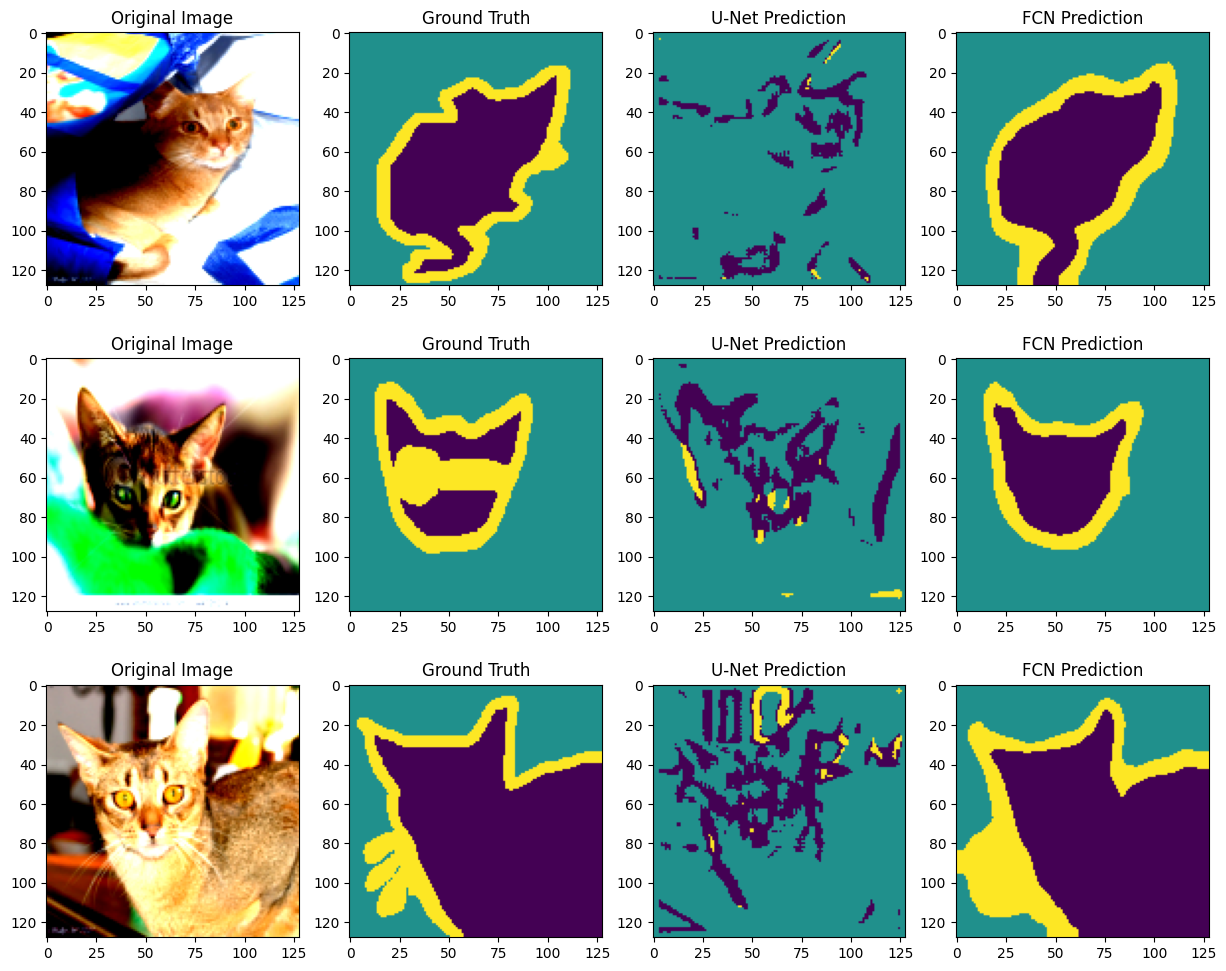

In [7]:
#7. Comparing using visualization
def visualize_comparison(unet, fcn, dataset, device, num_samples=3):
    unet.eval()
    fcn.eval()
    fig, axes = plt.subplots(num_samples, 4, figsize=(15, num_samples * 4))

    for i in range(num_samples):
        img, mask = dataset[i]
        img_input = img.unsqueeze(0).to(device)

        with torch.no_grad():
            # Get U-Net prediction
            u_pred = torch.argmax(unet(img_input), dim=1).squeeze(0).cpu().numpy()
            # Get FCN prediction
            f_pred = fcn(img_input)['out']
            f_pred = torch.argmax(f_pred, dim=1).squeeze(0).cpu().numpy()

        # Plotting
        axes[i, 0].imshow(img.permute(1, 2, 0).numpy() * 0.5 + 0.5) # Un-normalize
        axes[i, 0].set_title("Original Image")
        axes[i, 1].imshow(mask.numpy())
        axes[i, 1].set_title("Ground Truth")
        axes[i, 2].imshow(u_pred)
        axes[i, 2].set_title("U-Net Prediction")
        axes[i, 3].imshow(f_pred)
        axes[i, 3].set_title("FCN Prediction")

    plt.show()

# Run the visualization
visualize_comparison(my_unet, my_fcn, train_dataset, device)